# What the D-optimal allocator actually does

Four hand-built circuits, chosen so the right answer can be derived on a whiteboard, then
handed to the real `allocate_shots_per_circuit`. **No noise model, no gate set, no GST** --
this is the allocation protocol on its own, where correctness is checkable by inspection.

The one-sentence result, which the rest of the notebook establishes:

> **Shots follow uniqueness, not strength.**

### What "information" means here

Each circuit has two outcomes. Its Fisher information per shot, for parameter `theta`, is

    info = (dp/dtheta)^2 / (p (1-p))
            ^ gradient      ^ variance of ONE shot

The operational reading is `info = 1 / (variance per shot)`: spend `n` shots on a circuit of
information `a` and your estimate of that parameter has variance `1/(n a)`. A circuit with
`info = 100` pins its parameter down 10,000x faster per shot than one with `info = 0.01`.

Every circuit below is built with `p = 1/2`, so the denominator is identical throughout and
the demonstration is purely about **gradients** -- which direction in parameter space each
circuit can see, and how strongly.

### Why this is the interesting question

In real GST the gradient magnitude is dominated by circuit **depth**: repeating a germ `L`
times amplifies its error `L`-fold, so `dp/dtheta ~ L` and information `~ L^2`. Across a
1..64 ladder that is a spread of 1 to 4096. The toy numbers below stand in for that spread.

## The four circuits

Each is specified by its gradient -- how much its measured probability moves when each
parameter is nudged.

| circuit | dp/dtheta0 | dp/dtheta1 | what it is |
|---|---|---|---|
| **A** | 5.0 | 0 | strong, and the only source for theta0 |
| **B** | 3.5 | 0 | strong, but points the *same way* as A |
| **C** | 0 | 0.05 | 100x smaller gradient, but the only source for theta1 |
| **D** | 0 | 0 | its probabilities do not move at all |

**Work out the answer before running anything.** With `p = 1/2` the information is
`4 g^2`, so `A = 100`, `B = 49`, `C = 0.01`, `D = 0`, and

    det H(rho)  =  (100 n_A + 49 n_B) * (0.01 n_C)

- `D` contributes nothing to either factor, so `n_D = 0`.
- `B` enters only through the first factor, where `A` is worth twice as much per shot, so
  every shot given to `B` is better spent on `A`: `n_B = 0`.
- What is left is `max (100 n_A)(0.01 n_C)` subject to `n_A + n_C = N`, a product of two
  linear terms, maximised at `n_A = n_C = N/2`.

**Expected: A 50%, B 0%, C 50%, D 0%.**

Note what that means: `B`'s gradient is **70x larger than `C`'s**, and `B` gets nothing while
`C` gets half the budget.

In [1]:
import sys
from pathlib import Path

import numpy as np

SSE = Path.cwd()                                  # run from seed_sweep_experiments
sys.path.insert(0, str(SSE.parent))               # GST_POUNDERS, for adaptive_shots
import adaptive_shots as ashots

N_SHOTS = 1_000_000
BASELINE_FRAC = 0.001    # a token uniform floor; without ANY it is possible for the
                         # pseudo-determinant to reward a rank-deficient design

#            label                                    dp/dtheta0  dp/dtheta1
CIRCUITS = [("A  strong, only source for theta0",          5.0,       0.0),
            ("B  strong, but duplicates A",                3.5,       0.0),
            ("C  100x weaker, only source for theta1",     0.0,       0.05),
            ("D  probabilities ignore both",               0.0,       0.0)]
N_PARAMS = 2


def build(circuits, d):
    """Turn gradients into the (J, p, circuit_of_row) the allocator expects.

    Two outcomes per circuit with probabilities (1/2, 1/2) and gradients (+g, -g), so
        A_s = g g'/p + g g'/(1-p) = 4 g g'
    -- the per-shot Fisher information is 4x the outer product of the gradient, and the
    shot-noise denominator is the same for every circuit by construction.
    """
    J, p, row_circuit = [], [], []
    for s, (_, *g) in enumerate(circuits):
        g = np.array(g[:d], dtype=float)
        J += [g, -g]
        p += [0.5, 0.5]
        row_circuit += [s, s]
    return np.array(J), np.array(p), np.array(row_circuit)


J, p, row_circuit = build(CIRCUITS, N_PARAMS)
info = 4.0 * np.array([g0**2 + g1**2 for _, g0, g1 in CIRCUITS])
print(f"{'circuit':<42}{'gradient':>16}{'info/shot':>12}")
for (lab, g0, g1), a in zip(CIRCUITS, info):
    print(f"{lab:<42}{f'({g0:g}, {g1:g})':>16}{a:>12g}")

circuit                                           gradient   info/shot
A  strong, only source for theta0                   (5, 0)         100
B  strong, but duplicates A                       (3.5, 0)          49
C  100x weaker, only source for theta1           (0, 0.05)        0.01
D  probabilities ignore both                        (0, 0)           0


## Hand the circuits to the real allocator

This is `allocate_shots_per_circuit` from `adaptive_shots.py` -- the same function the sweep
calls, not a reimplementation. It is compared against two alternatives:

- **uniform** -- spread the budget evenly, which is what `lm` does
- **naive** -- spend in proportion to information: "put shots where the information is"

The naive one is the intuition most people reach for first, and it is worth seeing fail.

In [2]:
def d_efficiency(rho, reference):
    """(det H(rho) / det H(reference))^(1/d), both at the same total budget."""
    def H(r):
        w = np.asarray(r, dtype=float)[row_circuit] / p
        return (J * w[:, None]).T @ J + 1e-12 * np.eye(N_PARAMS)
    ev_r = np.linalg.eigvalsh(H(rho))
    ev_0 = np.linalg.eigvalsh(H(reference))
    return float(np.exp((np.sum(np.log(ev_r)) - np.sum(np.log(ev_0))) / N_PARAMS))


n = len(CIRCUITS)
baseline = np.full(n, BASELINE_FRAC * N_SHOTS / n)
extra, fw = ashots.allocate_shots_per_circuit(
    J, p, int((1 - BASELINE_FRAC) * N_SHOTS), row_circuit,
    n_circuit=baseline, criterion="D", max_iter=4000)

ALLOC = {"uniform": np.full(n, N_SHOTS / n),
         "naive": N_SHOTS * info / info.sum(),      # spend proportional to information
         "D-optimal": baseline + extra}
EXPECTED = np.array([50.0, 0.0, 50.0, 0.0])

print(f"{'circuit':<42}" + "".join(f"{k:>12}" for k in ALLOC) + f"{'expected':>11}")
for i, (lab, _, _) in enumerate(CIRCUITS):
    cells = "".join(f"{100 * ALLOC[k][i] / N_SHOTS:>11.1f}%" for k in ALLOC)
    print(f"{lab:<42}{cells}{EXPECTED[i]:>10.0f}%")

got = 100 * ALLOC["D-optimal"] / N_SHOTS
print(f"\nmatches the hand calculation to {np.abs(got - EXPECTED).max():.2f} percentage points"
      f"   -> {'PASS' if np.allclose(got, EXPECTED, atol=1.0) else 'FAIL'}")

print(f"\n{'':42}{'D-efficiency vs uniform':>32}")
for k, r in ALLOC.items():
    print(f"{k:<42}{d_efficiency(r, ALLOC['uniform']):>31.3f}x")

circuit                                        uniform       naive   D-optimal   expected
A  strong, only source for theta0                25.0%       67.1%       50.0%        50%
B  strong, but duplicates A                      25.0%       32.9%        0.0%         0%
C  100x weaker, only source for theta1           25.0%        0.0%       50.0%        50%
D  probabilities ignore both                     25.0%        0.0%        0.0%         0%

matches the hand calculation to 0.04 percentage points   -> PASS

                                                   D-efficiency vs uniform
uniform                                                             1.000x
naive                                                               0.024x
D-optimal                                                           1.638x


## What just happened

Each circuit is decided for a **different** reason, which is why four of them are enough to
state the whole rule:

| circuit | fate | because |
|---|---|---|
| A | half the budget | strong **and** irreplaceable |
| B | nothing | A already covers that direction, and does it better |
| C | half the budget | feeble, but **nothing else can see theta1** |
| D | nothing | contributes to no direction at all |

**The naive allocator is not merely worse -- it is far worse than doing nothing clever.**
Spending in proportion to information starves `theta1` down to 0.007% of the budget, so that
parameter is effectively unmeasured, `det H` collapses, and the design scores well below
uniform. That failure is the reason the criterion is a **determinant** and not a sum: a
determinant is zero if *any* direction is unmeasured, so it can never trade a direction away
no matter how much information sits elsewhere.

That is also why a small uniform baseline is kept in the real method: it guarantees every
direction has some coverage before the optimiser starts concentrating.

## The same rule, as a test suite

Six more cases with analytically known optima. These make good regression tests for
`allocate_shots_per_circuit` -- they run in about a second and would catch a change in its
behaviour immediately.

Test 2 is the one worth remembering: **two circuits, a 10,000x difference in information, and
the correct answer is still an even split**, because they inform different parameters and
`det H = (n0 a0)(n1 a1)` is maximised at equal `n` whatever `a0` and `a1` are. If circuits do
not compete, uniform is already optimal -- strength alone changes nothing.

In [3]:
def allocate(spec, d, N=1_000_000, baseline_frac=0.001):
    """spec = [(param_index_or_None, info_per_shot), ...]; returns percent of budget."""
    Jl, pl, rl = [], [], []
    for s, (j, a) in enumerate(spec):
        g = np.zeros(d)
        if j is not None:
            g[j] = np.sqrt(a) / 2.0            # info = 4 g^2  =>  g = sqrt(a)/2
        Jl += [g, -g]; pl += [0.5, 0.5]; rl += [s, s]
    k = len(spec)
    base = np.full(k, baseline_frac * N / k)
    ex, _ = ashots.allocate_shots_per_circuit(
        np.array(Jl), np.array(pl), int((1 - baseline_frac) * N), np.array(rl),
        n_circuit=base, criterion="D", max_iter=4000)
    return 100 * (base + ex) / N


TESTS = [
    ("1  disjoint params, equal strength",      [(0, 100.0), (1, 100.0)],              2, [50, 50]),
    ("2  disjoint params, 10,000x apart",       [(0, 10000.0), (1, 1.0)],              2, [50, 50]),
    ("3  a weak circuit competing with a strong one",
                                                [(0, 100.0), (0, 1.0), (1, 100.0)],    2, [50, 0, 50]),
    ("4  depth ladder, info ~ L^2",
     [(0, float(L * L)) for L in (1, 2, 4, 8, 16, 32, 64)] + [(1, 1.0)],               2,
     [0, 0, 0, 0, 0, 0, 50, 50]),
    ("5  a circuit that informs nothing",       [(0, 100.0), (1, 100.0), (None, 0.0)], 2, [50, 50, 0]),
    ("6  1,000,000x weaker, but the ONLY source for its parameter",
                                                [(0, 100.0), (1, 0.0001)],             2, [50, 50]),
]

for name, spec, d, expected in TESTS:
    got = allocate(spec, d)
    ok = np.allclose(got, expected, atol=1.5)
    shares = "  ".join(f"{v:5.1f}%" for v in got)
    print(f"{'PASS' if ok else 'FAIL'}  {name}")
    print(f"        expected  {'  '.join(f'{v:5.1f}%' for v in expected)}")
    print(f"        got       {shares}")

PASS  1  disjoint params, equal strength
        expected   50.0%   50.0%
        got        50.0%   50.0%
PASS  2  disjoint params, 10,000x apart
        expected   50.0%   50.0%
        got        50.0%   50.0%
PASS  3  a weak circuit competing with a strong one
        expected   50.0%    0.0%   50.0%
        got        50.0%    0.0%   50.0%


PASS  4  depth ladder, info ~ L^2
        expected    0.0%    0.0%    0.0%    0.0%    0.0%    0.0%   50.0%   50.0%
        got         0.0%    0.0%    0.0%    0.0%    0.0%    0.0%   50.0%   50.0%
PASS  5  a circuit that informs nothing
        expected   50.0%   50.0%    0.0%
        got        50.0%   50.0%    0.0%
PASS  6  1,000,000x weaker, but the ONLY source for its parameter
        expected   50.0%   50.0%
        got        50.0%   50.0%


## How many circuits get funded at all?

A natural next question is whether a circuit that is *mostly* redundant -- say gradient
`(3.5, 0.02)`, nearly parallel to A but with a sliver of `theta1` -- earns a partial share.

It does not, and the reason is structural rather than about overlap: **the support of a
D-optimal design tracks the number of PARAMETERS, not the number of circuits offered.** With
two parameters only about two circuits can ever be funded, however many are on the menu.

In [4]:
rng = np.random.default_rng(0)


def n_funded(d, n_circuits=20, N=1_000_000, baseline_frac=0.001):
    grads = [rng.standard_normal(d) for _ in range(n_circuits)]
    Jl, pl, rl = [], [], []
    for s, g in enumerate(grads):
        Jl += [g, -g]; pl += [0.5, 0.5]; rl += [s, s]
    base = np.full(n_circuits, baseline_frac * N / n_circuits)
    ex, _ = ashots.allocate_shots_per_circuit(
        np.array(Jl), np.array(pl), int((1 - baseline_frac) * N), np.array(rl),
        n_circuit=base, criterion="D", max_iter=4000)
    share = (base + ex) / N
    return int((share > 1.5 * baseline_frac / n_circuits).sum())


print(f"{'parameters d':>14}{'circuits offered':>18}{'circuits funded':>17}")
for d in (1, 2, 3, 5, 8, 12):
    print(f"{d:>14}{20:>18}{n_funded(d):>17}")
print()
print("So the four-circuit demo above cannot show a graded allocation -- with d=2 the")
print("optimal design has room for about two circuits and the rest are exactly zero.")
print("The real problem has 33 identifiable directions and funds 110 of its 1918 circuits,")
print("which is the same behaviour at a scale where it looks graded rather than binary.")

  parameters d  circuits offered  circuits funded


             1                20                1


             2                20                2


             3                20                6


             5                20                8


             8                20               13


            12                20               19

So the four-circuit demo above cannot show a graded allocation -- with d=2 the
optimal design has room for about two circuits and the rest are exactly zero.
The real problem has 33 identifiable directions and funds 110 of its 1918 circuits,
which is the same behaviour at a scale where it looks graded rather than binary.


## The figure

One picture of the four-circuit case: three allocation strategies, and what each is worth.

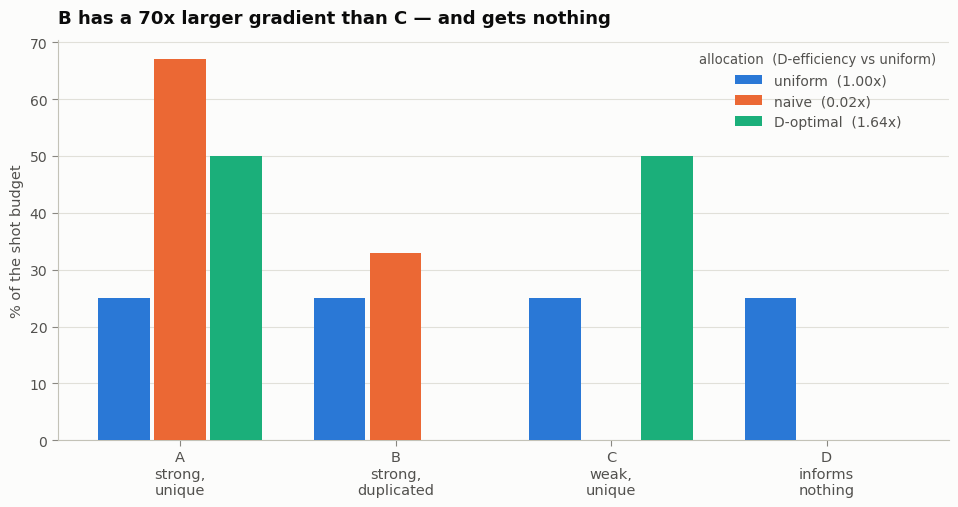

written: C:\Users\athar\Documents\Codex\ANL_SummerInternship\can-you-write-a-code-for\IBCDFO\GST_POUNDERS\seed_sweep_experiments\allocator_demo.png


In [5]:
import matplotlib.pyplot as plt

# Palette: slots 1-3 of the validated categorical set, fixed per strategy.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a"]

fig, ax = plt.subplots(figsize=(11.5, 5.2), facecolor=SURFACE)
labels = ["A\nstrong,\nunique", "B\nstrong,\nduplicated", "C\nweak,\nunique",
          "D\ninforms\nnothing"]
x = np.arange(len(labels))
w = 0.26
for k, (name, colour) in enumerate(zip(ALLOC, COLOURS)):
    eff = d_efficiency(ALLOC[name], ALLOC["uniform"])
    ax.bar(x + (k - 1) * w, 100 * ALLOC[name] / N_SHOTS, width=w * 0.92, color=colour,
           label=f"{name}  ({eff:.2f}x)", zorder=3)

ax.set_facecolor(SURFACE)
ax.grid(True, axis="y", color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.set_xticks(x)
ax.set_xticklabels(labels, color=INK2, fontsize=10.5)
ax.tick_params(colors=MUTED, labelcolor=INK2, length=4)
ax.set_ylabel("% of the shot budget", color=INK2, fontsize=10.5)
ax.set_title("B has a 70x larger gradient than C — and gets nothing",
             color=INK, fontsize=13, fontweight="semibold", loc="left", pad=12)
leg = ax.legend(frameon=False, fontsize=10, title="allocation  (D-efficiency vs uniform)")
leg.get_title().set_color(INK2)
leg.get_title().set_fontsize(9.5)
for t in leg.get_texts():
    t.set_color(INK2)

fig.savefig(SSE / "allocator_demo.png", dpi=170, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"written: {SSE / 'allocator_demo.png'}")

## The same four cases, on real circuits

Everything above used gradients I wrote down. This section builds **actual GST circuits**,
takes their **actual Jacobian rows from the model**, and hands those to the same allocator.

*(This is the only section that needs pyGSTi.)*

A GST circuit is `prep fiducial . germ^L . measurement fiducial`, and the two halves do
different jobs:

- the **germ and its depth** decide which error components are amplified, and by how much
- the **fiducials** decide which of them are *visible* in the measurement

The four circuits below hold the germ and depth fixed and vary only the **measurement
fiducial**, so the demonstration isolates visibility from amplification. `D` is the exception
and is the nicest one: prepare |0>, idle, measure Z. The state never leaves |0>, so the
circuit contains an error it structurally cannot see.

In [6]:
import sys as _sys
_sys.path.insert(0, str(SSE))
from gst_seed_experiment import ExperimentConfig, GSTProblem, _make_parameterized_model

cfg = ExperimentConfig.from_json(SSE / "experiment_config.json")
prob = GSTProblem(cfg, 101)
mp = prob.modelpack
pf, mf, germs = mp.prep_fiducials(), mp.meas_fiducials(), mp.germs()
truth = _make_parameterized_model(prob.truth_model, cfg.parameterization,
                                  ideal_model=prob.raw_target_model)

gx = [g for g in germs if len(g) == 1 and "Gxpi2" in str(g)][0]
idle = [g for g in germs if len(g) == 1 and not any(k in str(g)
        for k in ("Gxpi2", "Gypi2", "Gzpi2"))][0]

REAL = [("A  Gxpi2^32, meas fid 3", pf[1] + gx * 32 + mf[3]),
        ("B  Gxpi2^32, meas fid 0", pf[1] + gx * 32 + mf[0]),
        ("C  Gxpi2^32, meas fid 2", pf[1] + gx * 32 + mf[2]),
        ("D  idle^4, prep0 meas0",  pf[0] + idle * 4 + mf[0])]

circuits = [c for _, c in REAL]
pr = truth.bulk_probabilities(circuits)
dp = truth.sim.bulk_dprobs(circuits)

Jr, pr_vec, rc = [], [], []
for s, (_, c) in enumerate(REAL):
    for o in truth.probabilities(c).keys():
        pr_vec.append(float(pr[c].get(o, 0.0)))
        Jr.append(np.asarray(dp[c][o], dtype=float))
        rc.append(s)
Jr, pr_vec, rc = np.array(Jr), np.array(pr_vec), np.array(rc)

# one gradient per circuit (first outcome) for the geometry table
grad = {lab: np.asarray(dp[c][list(truth.probabilities(c).keys())[0]], dtype=float)
        for lab, c in REAL}
labs = list(grad)
print(f"{'circuit':<26}{'p':>9}{'|gradient|':>14}")
for lab, c in REAL:
    o = list(truth.probabilities(c).keys())[0]
    print(f"{lab:<26}{float(pr[c].get(o, 0.0)):>9.4f}{np.linalg.norm(grad[lab]):>14.3e}")

print()
gA, gB = grad[labs[0]], grad[labs[1]]
resid = gB - (gA @ gB / (gA @ gA)) * gA
print(f"B component orthogonal to A: {np.linalg.norm(resid):.3e}  "
      f"({100 * np.linalg.norm(resid) / np.linalg.norm(gB):.3f}% of |B|) -- small, not zero")
print()
print("cosine between gradients  (magnitude; 1.000 = parallel, 0 = independent)")
print(f"{'':26}" + "".join(f"{l[0]:>9}" for l in labs))
for a in labs:
    row = ""
    for b in labs:
        na, nb = np.linalg.norm(grad[a]), np.linalg.norm(grad[b])
        row += f"{abs(float(grad[a] @ grad[b] / (na * nb))):>9.3f}"
    print(f"{a:<26}{row}")

circuit                           p    |gradient|
A  Gxpi2^32, meas fid 3      0.5118     2.712e+01
B  Gxpi2^32, meas fid 0      0.4892     2.595e+01
C  Gxpi2^32, meas fid 2      0.4948     2.723e+00
D  idle^4, prep0 meas0       0.9995     2.423e-06

B component orthogonal to A: 1.439e-01  (0.555% of |B|) -- small, not zero

cosine between gradients  (magnitude; 1.000 = parallel, 0 = independent)
                                  A        B        C        D
A  Gxpi2^32, meas fid 3       1.000    1.000    0.132    0.002
B  Gxpi2^32, meas fid 0       1.000    1.000    0.133    0.002
C  Gxpi2^32, meas fid 2       0.132    0.133    1.000    0.025
D  idle^4, prep0 meas0        0.002    0.002    0.025    1.000


### And the allocation -- which does NOT reproduce the toy

The toy had `B` exactly parallel to `A`, because that is how it was built. Real circuits are
never exactly parallel, and the difference decides the outcome:

    cos(A, B) = 0.99998        B's component orthogonal to A = 0.555% of |B|

That 0.555% is a direction **nothing else in the set can see**, and `det H` is zero if any
direction goes unmeasured. So `B` is funded, and funded equally, despite carrying almost no
new information. That is the same rule pushed to its extreme: half a percent of a new
direction earns a full share, while a large gradient pointing where `A` already points earns
nothing.

`D` still gets nothing -- its gradient is `2.4e-06`, seven orders of magnitude below the
rest, so the token baseline already covers that direction as well as anything could.

The lesson for the real problem: allocations there are **graded rather than all-or-nothing**,
because real circuits are almost-but-not-quite redundant. The clean 50/0/50/0 of the toy is a
limiting case you can build on paper and will never meet in a gate set.

In [7]:
nr = len(REAL)
base_r = np.full(nr, BASELINE_FRAC * N_SHOTS / nr)
extra_r, _ = ashots.allocate_shots_per_circuit(
    Jr, pr_vec, int((1 - BASELINE_FRAC) * N_SHOTS), rc,
    n_circuit=base_r, criterion="D", max_iter=4000)
share_r = 100 * (base_r + extra_r) / N_SHOTS

print(f"{'circuit':<26}{'|gradient|':>13}{'D-optimal':>12}{'toy analogue':>15}")
for i, (lab, _) in enumerate(REAL):
    toy = 100 * ALLOC["D-optimal"][i] / N_SHOTS
    print(f"{lab:<26}{np.linalg.norm(grad[lab]):>13.2e}{share_r[i]:>11.1f}%{toy:>14.1f}%")

print()
print("A, B and C are the SAME 32-gate sequence; only the measurement fiducial")
print("differs, and that alone changes the gradient 10x and its direction entirely.")
print()
print("They split evenly because each contributes an identifiable direction -- even B,")
print("whose gradient is 99.998% parallel to A. Only D is dropped, for the one reason")
print("that survives in practice: its measurement cannot see the error it contains.")

circuit                      |gradient|   D-optimal   toy analogue
A  Gxpi2^32, meas fid 3        2.71e+01       33.3%          50.0%
B  Gxpi2^32, meas fid 0        2.59e+01       33.3%           0.0%
C  Gxpi2^32, meas fid 2        2.72e+00       33.3%          50.0%
D  idle^4, prep0 meas0         2.42e-06        0.0%           0.0%

A, B and C are the SAME 32-gate sequence; only the measurement fiducial
differs, and that alone changes the gradient 10x and its direction entirely.

They split evenly because each contributes an identifiable direction -- even B,
whose gradient is 99.998% parallel to A. Only D is dropped, for the one reason
that survives in practice: its measurement cannot see the error it contains.
